# 03. Model Tuning - Job Salary Prediction

Hyperparameter tuning for XGBoost baseline using RandomizedSearchCV (faster) or Optuna.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


In [3]:
# Load splits (same as baseline)
train = pd.read_csv('C:/Users/Manikanth Reddy/Documents/dev/Jobs/data/train.csv')
test = pd.read_csv('C:/Users/Manikanth Reddy/Documents/dev/Jobs/data/test.csv')

print(f'Train: {train.shape}, Test: {test.shape}')
print('Target stats:')
print(train['avg_ctc'].describe())

Train: (3600, 18), Test: (901, 18)
Target stats:
count      3461.000000
mean     335544.199075
std      133965.924218
min        1440.000000
25%      230000.000000
50%      300000.000000
75%      400000.000000
max      675000.000000
Name: avg_ctc, dtype: float64


In [4]:
# Features (same preprocessing)
features = ['min_exp', 'max_exp', 'posted_days']

# Top 20 encoding (reuse baseline logic)
top_jobs = train['job_title'].value_counts().head(20).index
train['job_top'] = pd.Categorical(train['job_title'].where(train['job_title'].isin(top_jobs), 'Other'))
test['job_top'] = pd.Categorical(test['job_title'].where(test['job_title'].isin(top_jobs), 'Other'))

top_locations = train['location'].value_counts().head(20).index
train['loc_top'] = pd.Categorical(train['location'].where(train['location'].isin(top_locations), 'Other'))
test['loc_top'] = pd.Categorical(test['location'].where(test['location'].isin(top_locations), 'Other'))

# Dummies
all_features = features + ['job_top', 'loc_top']
X_train = pd.get_dummies(train[all_features], drop_first=True)
y_train = train['avg_ctc'].fillna(train['avg_ctc'].median())

X_test = pd.get_dummies(test[all_features], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test['avg_ctc'].fillna(train['avg_ctc'].median())

print(f'Features: {X_train.shape[1]}')
print(X_train.head())

Features: 43
   min_exp  max_exp  posted_days  job_top_Business Development Associate  \
0        1        3           21                                   False   
1        0        5           14                                    True   
2        1        3            6                                   False   
3        0        2            7                                   False   
4        0        2           14                                   False   

   job_top_Business Development Executive  \
0                                   False   
1                                   False   
2                                   False   
3                                   False   
4                                   False   

   job_top_Business Development Manager  job_top_Content Writer  \
0                                 False                   False   
1                                 False                   False   
2                                 False                   

In [5]:
# Baseline recall (load and eval)
baseline_model = joblib.load('baseline_salary_model.joblib')
y_pred_baseline = baseline_model.predict(X_test)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)
print(f'Baseline - MAE: ₹{mae_baseline:,.0f}, R²: {r2_baseline:.3f}')

Baseline - MAE: ₹65,118, R²: 0.582


In [6]:
# RandomizedSearchCV tuning
model = XGBRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# TimeSeriesSplit for temporal data (sort by posted_days?)
tscv = TimeSeriesSplit(n_splits=5)
random_search = RandomizedSearchCV(
    model, param_distributions=param_dist, n_iter=100, 
    cv=tscv, scoring='neg_mean_absolute_error', 
    random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train, y_train)
print('Best params:', random_search.best_params_)
print('Best CV score:', -random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV score: 65702.31051041666


Tuned - MAE: ₹63,326 (2.8% improvement), R²: 0.617


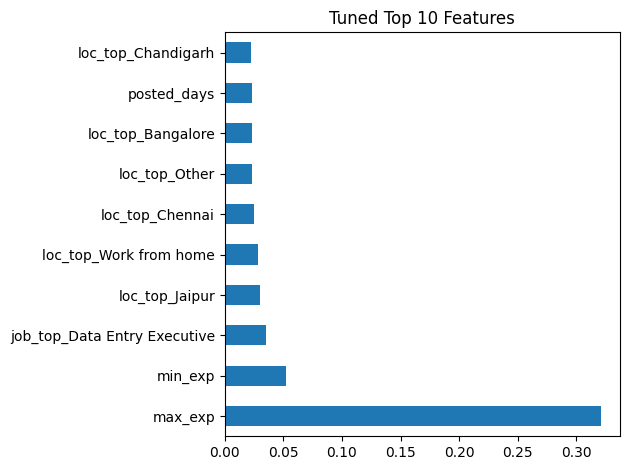

✅ Tuned model saved!


In [7]:
# Test tuned model
best_model = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f'Tuned - MAE: ₹{mae_tuned:,.0f} ({((mae_baseline - mae_tuned)/mae_baseline)*100:.1f}% improvement), R²: {r2_tuned:.3f}')

# Feature importance
importance = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importance.head(10).plot(kind='barh', title='Tuned Top 10 Features')
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

# Save best model
joblib.dump(best_model, 'tuned_salary_model.joblib')
print('✅ Tuned model saved!')

## Next Steps
- Run tuning (may take 10-30min)
- Compare results
- Mark TODO.md step 4-5 complete
- Optional: Try Optuna for more advanced tuning
```python
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        # ... etc
    }
    # CV score
    return score

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
```